In [1]:
#use top 50 feature importanace from trial 1

#add 2 columns for gdp by city proper metro area

#add categorical variables


In [2]:
# Target variable 'spread_a' is most predicted by stat differences which should be used.

random_state_2909 = 2909

# 4 Pre-Processing and Training Data<a id='4_Pre-Processing_and_Training_Data'></a>

## 4.2 Introduction<a id='4.2_Introduction'></a>

## 4.3 Imports<a id='4.3_Imports'></a>

In [3]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

pd.options.display.max_columns = 999
pd.options.display.max_rows = 999

## 4.4 Functions<a id='4.4_Imports'></a>

In [4]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_


In [5]:
# This isn't exactly production-grade, but a quick check for development
# These checks can save some head-scratching in development when moving from
# one python environment to another, for example
expected_model_version = '1.0'
model_path = os.path.join('..','models', '172_model_training_trial_2.pkl')
if os.path.exists(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    if model.version != expected_model_version:
        print("Expected model version doesn't match version loaded")
    if model.sklearn_version != sklearn_version:
        print("Warning: model created under different sklearn version")
else:
    print("Expected model not found")

/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator DecisionTreeRegressor from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator RandomForestRegressor from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator Pipeline from version 0.22 when using version 0.23.2. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(


In [6]:
model_172_model_training_trial_2 = model
model_172_model_training_trial_2

Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(criterion='mae', max_depth=5,
                                       min_samples_split=100, n_estimators=200,
                                       random_state=47))])

In [7]:
model_172_model_training_trial_2.set_params

<bound method Pipeline.set_params of Pipeline(steps=[('randomforestregressor',
                 RandomForestRegressor(criterion='mae', max_depth=5,
                                       min_samples_split=100, n_estimators=200,
                                       random_state=47))])>

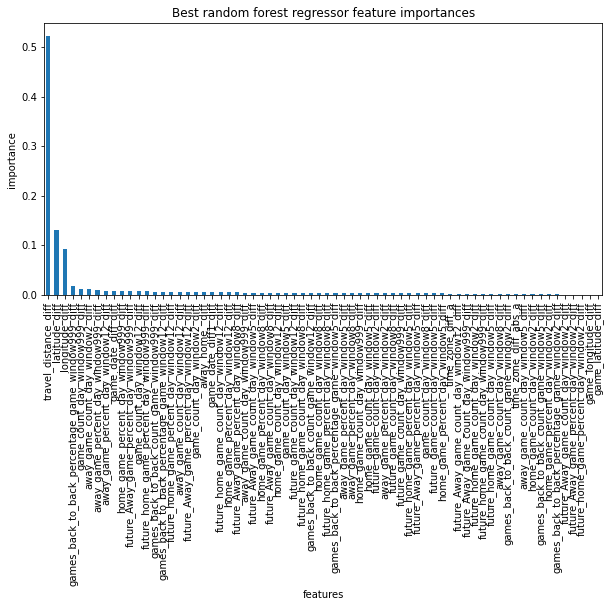

In [8]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = model_172_model_training_trial_2.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=model_172_model_training_trial_2.X_columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

In [9]:
print(len(rf_feat_imps[0:50]))
rf_feat_imps[0:50]

50


travel_distance_diff                                 0.522727
latitude_diff                                        0.130294
longitude_diff                                       0.092645
games_back_to_back_percentage_game_window999_diff    0.018119
game_count_day_window999_diff                        0.010663
away_game_count_day_window2_diff                     0.010662
away_game_percent_day_window999_diff                 0.008661
away_game_percent_day_window12_diff                  0.008061
game_date_diff_diff                                  0.007776
home_game_percent_day_window999_diff                 0.007652
future_Away_game_percent_day_window999_diff          0.007506
game_count_day_window12_diff                         0.007128
future_home_game_percent_day_window999_diff          0.007013
games_back_to_back_count_game_window999_diff         0.006267
games_back_to_back_percentage_game_window12_diff     0.006137
future_home_game_percent_day_window12_diff           0.005981
away_gam

In [10]:
rf_feat_imps_top_50_list = list(rf_feat_imps[0:50].index)
pl(rf_feat_imps_top_50_list)

50


['travel_distance_diff',
 'latitude_diff',
 'longitude_diff',
 'games_back_to_back_percentage_game_window999_diff',
 'game_count_day_window999_diff',
 'away_game_count_day_window2_diff',
 'away_game_percent_day_window999_diff',
 'away_game_percent_day_window12_diff',
 'game_date_diff_diff',
 'home_game_percent_day_window999_diff',
 'future_Away_game_percent_day_window999_diff',
 'game_count_day_window12_diff',
 'future_home_game_percent_day_window999_diff',
 'games_back_to_back_count_game_window999_diff',
 'games_back_to_back_percentage_game_window12_diff',
 'future_home_game_percent_day_window12_diff',
 'away_game_count_day_window12_diff',
 'future_Away_game_percent_day_window12_diff',
 'game_count_day_window2_diff',
 'away_home__diff',
 'game_date_diff1_diff',
 'future_home_game_count_day_window12_diff',
 'home_game_percent_day_window12_diff',
 'future_Away_game_percent_day_window8_diff',
 'away_game_count_day_window999_diff',
 'future_Away_game_count_day_window5_diff',
 'home_game_p

In [11]:
rf_feat_imps_sub_50_list = list(rf_feat_imps[50:].index)
pl(rf_feat_imps_sub_50_list)

18


['future_Away_game_count_day_window12_diff',
 'future_Away_game_count_day_window999_diff',
 'future_home_game_count_day_window2_diff',
 'future_home_game_count_day_window999_diff',
 'future_home_game_count_day_window5_diff',
 'away_game_count_day_window8_diff',
 'games_back_to_back_count_game_window2_diff',
 'time_zone_diff_abs_a',
 'away_game_count_day_window5_diff',
 'home_game_count_day_window2_diff',
 'games_back_to_back_count_game_window5_diff',
 'home_game_percent_day_window2_diff',
 'games_back_to_back_percentage_game_window2_diff',
 'future_Away_game_count_day_window2_diff',
 'future_Away_game_percent_day_window2_diff',
 'future_home_game_percent_day_window2_diff',
 'game_longitude_diff',
 'game_latitude_diff']

## 4.5 Load Data<a id='4.5_Load_Data'></a>

In [12]:
df_stats = rcp('53AAprediction_stats_2010_2018.csv', ['game_date'])
p(df_stats)

(10266, 107)


,game_id,TEAM_NAME_a,TEAM_ABBREVIATION_a,TEAM_CITY_a,team_id_a,spread_a,away_home_a,game_date,matchup,season_type,season,TEAM_NAME_b,TEAM_ABBREVIATION_b,TEAM_CITY_b,team_id_b,E_OFF_RATING_cma_diff,OFF_RATING_cma_diff,E_DEF_RATING_cma_diff,DEF_RATING_cma_diff,E_NET_RATING_cma_diff,NET_RATING_cma_diff,AST_PCT_cma_diff,AST_TOV_cma_diff,AST_RATIO_cma_diff,OREB_PCT_cma_diff,DREB_PCT_cma_diff,REB_PCT_cma_diff,E_TM_TOV_PCT_cma_diff,TM_TOV_PCT_cma_diff,EFG_PCT_cma_diff,TS_PCT_cma_diff,USG_PCT_cma_diff,E_USG_PCT_cma_diff,E_PACE_cma_diff,PACE_cma_diff,PACE_PER40_cma_diff,POSS_cma_diff,PIE_cma_diff,duration_minutes_cma_diff,w_pct_cma_diff,min_cma_diff,fgm_cma_diff,fga_cma_diff,fg_pct_cma_diff,fg3m_cma_diff,fg3a_cma_diff,fg3_pct_cma_diff,ftm_cma_diff,fta_cma_diff,ft_pct_cma_diff,oreb_cma_diff,dreb_cma_diff,reb_cma_diff,ast_cma_diff,stl_cma_diff,blk_cma_diff,tov_cma_diff,pf_cma_diff,pts_cma_diff,spread_cma_diff,away_home_cma_diff,E_OFF_RATING_sm_cma_diff,OFF_RATING_sm_cma_diff,E_DEF_RATING_sm_cma_diff,DEF_RATING_sm_cma_diff,E_NET_RATING_sm_cma_diff,NET_RATING_sm_cma_diff,AST_PCT_sm_cma_diff,AST_TOV_sm_cma_diff,AST_RATIO_sm_cma_diff,OREB_PCT_sm_cma_diff,DREB_PCT_sm_cma_diff,REB_PCT_sm_cma_diff,E_TM_TOV_PCT_sm_cma_diff,TM_TOV_PCT_sm_cma_diff,EFG_PCT_sm_cma_diff,TS_PCT_sm_cma_diff,USG_PCT_sm_cma_diff,E_USG_PCT_sm_cma_diff,E_PACE_sm_cma_diff,PACE_sm_cma_diff,PACE_PER40_sm_cma_diff,POSS_sm_cma_diff,PIE_sm_cma_diff,duration_minutes_sm_cma_diff,w_pct_sm_cma_diff,min_sm_cma_diff,fgm_sm_cma_diff,fga_sm_cma_diff,fg_pct_sm_cma_diff,fg3m_sm_cma_diff,fg3a_sm_cma_diff,fg3_pct_sm_cma_diff,ftm_sm_cma_diff,fta_sm_cma_diff,ft_pct_sm_cma_diff,oreb_sm_cma_diff,dreb_sm_cma_diff,reb_sm_cma_diff,ast_sm_cma_diff,stl_sm_cma_diff,blk_sm_cma_diff,tov_sm_cma_diff,pf_sm_cma_diff,pts_sm_cma_diff,spread_sm_cma_diff,away_home_sm_cma_diff
0,21000001,Celtics,BOS,Boston,1610612738,-8,1,2010-10-26,BOS vs. MIA,Regular Season,2010-11,Heat,MIA,Miami,1610612748,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,21000002,Suns,PHX,Phoenix,1610612756,14,0,2010-10-26,PHX vs. POR,Regular Season,2010-11,Trail Blazers,POR,Portland,1610612757,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,21000003,Rockets,HOU,Houston,1610612745,2,0,2010-10-26,HOU vs. LAL,Regular Season,2010-11,Lakers,LAL,Los Angeles,1610612747,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.

In [13]:
df_stats_gitiab_spread = df_stats.loc[:, ['game_id', 'team_id_a', 'team_id_b', 'spread_a']]
p(df_stats_gitiab_spread)

(10266, 4)


,game_id,team_id_a,team_id_b,spread_a
0,21000001,1610612738,1610612748,-8
1,21000002,1610612756,1610612757,14
2,21000003,1610612745,1610612747,2
3,21000009,1610612750,1610612758,1
4,21000006,1610612748,1610612755,-10
10261,41700317,1610612744,1610612745,-9
10262,41700401,1610612739,1610612744,10
10263,41700402,1610612739,1610612744,19
10264,41700403,1610612739,1610612744,8
10265,41700404,1610612739,1610612744,23


In [14]:
df = rcp('72_71C_schedule_location_differences_2010_2018.csv', ['game_date'])
p(df)

(10266, 85)


,game_id,team_id_a,game_date,season,game_time_zone_a,time_zone_a,time_zone_diff_a,time_zone_diff_abs_a,city_proper_metro_area_a,Country/Region_a,city_proper_metro_area_GDP_bil_a,city_proper_metro_area_GDP_bil1_a,team_id_b,game_time_zone_b,time_zone_b,city_proper_metro_area_b,Country/Region_b,city_proper_metro_area_GDP_bil_b,city_proper_metro_area_GDP_bil1_b,away_home__diff,latitude_diff,longitude_diff,game_latitude_diff,game_longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window2_diff,games_back_to_back_count_game_window5_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window2_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,home_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_percent_day_window2_diff,away_game_count_day_window5_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,away_game_count_day_window8_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_Away_game_count_day_window2_diff,future_home_game_count_day_window2_diff,future_game_count_day_window2_diff,future_Away_game_percent_day_window2_diff,future_home_game_percent_day_window2_diff,future_Away_game_count_day_window5_diff,future_home_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_Away_game_count_day_window12_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_Away_game_count_day_window999_diff,future_home_game_count_day_window999_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,21000001,1610612738,2010-10-26,2010-11,America/New_York,America/New_York,0,0,Boston,United States,463.570,560.1,1610612748,America/New_York,America/New_York,Miami,United States,377.5,262.7,1.0,16.586081,9.135329,0.0,0.0,-1257.755091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,1.0,0.0,-1.0,1.0,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-0.5,0.5,-1.0,1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,-2.0,1.0,-1.0,-0.238095,0.238095,0.0,0.0,0.0,0.000000,0.000000
1,21000002,1610612756,2010-10-26,2010-11,America/Los_Angeles,America/Phoenix,0,0,Phoenix,United States,255.211,607.1,1610612757,America/Los_Angeles,America/Los_Angeles,Portland,United States,164.419,158.5,-1.0,-12.071810,10.600053,0.0,0.0,1005.606855,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,-1.0,0.0,1.0,-1.0,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,0.0,-1.0,-1.0,0.5,-0.5,0.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,-2.0,0.0,-2.0,-0.171429,0.171429,0.0,0.0,0.0,0.000000,0.000000
2,21000003,1610612745,2010-10-26,2010-11,America/Los_Angeles,America/Chicago,-2,2,Houston,United States,

In [15]:
df.drop(columns=rf_feat_imps_sub_50_list, inplace=True)
p(df)

(10266, 67)


,game_id,team_id_a,game_date,season,game_time_zone_a,time_zone_a,time_zone_diff_a,city_proper_metro_area_a,Country/Region_a,city_proper_metro_area_GDP_bil_a,city_proper_metro_area_GDP_bil1_a,team_id_b,game_time_zone_b,time_zone_b,city_proper_metro_area_b,Country/Region_b,city_proper_metro_area_GDP_bil_b,city_proper_metro_area_GDP_bil1_b,away_home__diff,latitude_diff,longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_game_count_day_window2_diff,future_Away_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,21000001,1610612738,2010-10-26,2010-11,America/New_York,America/New_York,0,Boston,United States,463.570,560.1,1610612748,America/New_York,America/New_York,Miami,United States,377.5,262.7,1.0,16.586081,9.135329,-1257.755091,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,0.0,-1.0,1.0,0.0,-1.000000,1.000000,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,0.0,-1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,1.0,-1.0,-0.238095,0.238095,0.0,0.000000,0.000000
1,21000002,1610612756,2010-10-26,2010-11,America/Los_Angeles,America/Phoenix,0,Phoenix,United States,255.211,607.1,1610612757,America/Los_Angeles,America/Los_Angeles,Portland,United States,164.419,158.5,-1.0,-12.071810,10.600053,1005.606855,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,0.0,-2.0,-0.171429,0.171429,0.0,0.000000,0.000000
2,21000003,1610612745,2010-10-26,2010-11,America/Los_Angeles,America/Chicago,-2,Houston,United States,478.778,883.2,1610612747,America/Los_Angeles,America/Los_Angeles,Los Angeles,United States,"1,048","1,528.27",-1.0,-4.294753,22.875069,1371.020326,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,1.0,1.0,0.166667,-0.166667,1.0,-2.0,-1.0,0.416667,-0.416667,-2.0,-1.0,0.266667,-0.266667,0.0,0.000000,0.000000
3,21000006,1610612748,2010-10-27,2010-11,America/New_York,America/New_York,0,Miami,United States,377.5,262.7,1610612755,America/New_York,America/New_York,Philadelphia,United States,444.148,746.5,-1.0,-14.178551,-5.030094,1021.727021,-8.0,1.0,1.0,1.0,0.5,0.5,0.500000,2.0,1.0,1.0,-1.0,1.0,1.000000,-1.000000,-1.0,1.0,1.000000,-1.000000,2.0,-1.0,1.0,1.000000,-1.000000,2.0,-1.0,1.0,1.

In [16]:
df_stats_gitiab_spread.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10266 entries, 0 to 10265
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   game_id    10266 non-null  int64
 1   team_id_a  10266 non-null  int64
 2   team_id_b  10266 non-null  int64
 3   spread_a   10266 non-null  int64
dtypes: int64(4)
memory usage: 320.9 KB


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10266 entries, 0 to 10265
Data columns (total 67 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   game_id                                            10266 non-null  int64         
 1   team_id_a                                          10266 non-null  int64         
 2   game_date                                          10266 non-null  datetime64[ns]
 3   season                                             10266 non-null  object        
 4   game_time_zone_a                                   10266 non-null  object        
 5   time_zone_a                                        10266 non-null  object        
 6   time_zone_diff_a                                   10266 non-null  int64         
 7   city_proper_metro_area_a                           10266 non-null  object        
 8   Country/Region_a

In [18]:
#merge
df = pd.merge(df_stats_gitiab_spread,
              df,
              on=['game_id', 'team_id_a', 'team_id_b'],)
p(df)

(10266, 68)


,game_id,team_id_a,team_id_b,spread_a,game_date,season,game_time_zone_a,time_zone_a,time_zone_diff_a,city_proper_metro_area_a,Country/Region_a,city_proper_metro_area_GDP_bil_a,city_proper_metro_area_GDP_bil1_a,game_time_zone_b,time_zone_b,city_proper_metro_area_b,Country/Region_b,city_proper_metro_area_GDP_bil_b,city_proper_metro_area_GDP_bil1_b,away_home__diff,latitude_diff,longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_game_count_day_window2_diff,future_Away_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,21000001,1610612738,1610612748,-8,2010-10-26,2010-11,America/New_York,America/New_York,0,Boston,United States,463.570,560.1,America/New_York,America/New_York,Miami,United States,377.5,262.7,1.0,16.586081,9.135329,-1257.755091,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,0.0,-1.0,1.0,0.0,-1.000000,1.000000,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,0.0,-1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,1.0,-1.0,-0.238095,0.238095,0.0,0.000000,0.000000
1,21000002,1610612756,1610612757,14,2010-10-26,2010-11,America/Los_Angeles,America/Phoenix,0,Phoenix,United States,255.211,607.1,America/Los_Angeles,America/Los_Angeles,Portland,United States,164.419,158.5,-1.0,-12.071810,10.600053,1005.606855,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,0.0,-2.0,-0.171429,0.171429,0.0,0.000000,0.000000
2,21000003,1610612745,1610612747,2,2010-10-26,2010-11,America/Los_Angeles,America/Chicago,-2,Houston,United States,478.778,883.2,America/Los_Angeles,America/Los_Angeles,Los Angeles,United States,"1,048","1,528.27",-1.0,-4.294753,22.875069,1371.020326,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,1.0,1.0,0.166667,-0.166667,1.0,-2.0,-1.0,0.416667,-0.416667,-2.0,-1.0,0.266667,-0.266667,0.0,0.000000,0.000000
3,21000009,1610612750,1610612758,1,2010-10-27,2010-11,America/Chicago,America/Chicago,0,Minneapolis/St. Paul,United States,263.690,211.4,America/Chicago,America/Los_Angeles,Sacramento,United States,145.479,127.4,1.0,6.396239,28.228426,-1511.318417,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,0.0,-1.0,1.0,0.0,-1.000000,1.000000,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.

In [19]:
column_name_list = list(df.columns)
pl(column_name_list)

68


['game_id',
 'team_id_a',
 'team_id_b',
 'spread_a',
 'game_date',
 'season',
 'game_time_zone_a',
 'time_zone_a',
 'time_zone_diff_a',
 'city_proper_metro_area_a',
 'Country/Region_a',
 'city_proper_metro_area_GDP_bil_a',
 'city_proper_metro_area_GDP_bil1_a',
 'game_time_zone_b',
 'time_zone_b',
 'city_proper_metro_area_b',
 'Country/Region_b',
 'city_proper_metro_area_GDP_bil_b',
 'city_proper_metro_area_GDP_bil1_b',
 'away_home__diff',
 'latitude_diff',
 'longitude_diff',
 'travel_distance_diff',
 'game_date_diff_diff',
 'game_date_diff1_diff',
 'games_back_to_back_count_game_window12_diff',
 'games_back_to_back_count_game_window999_diff',
 'games_back_to_back_percentage_game_window5_diff',
 'games_back_to_back_percentage_game_window12_diff',
 'games_back_to_back_percentage_game_window999_diff',
 'away_game_count_day_window2_diff',
 'game_count_day_window2_diff',
 'away_game_percent_day_window2_diff',
 'home_game_count_day_window5_diff',
 'game_count_day_window5_diff',
 'away_game_p

## 4.6 Get Indicator Variables<a id='4.6 Get_Indicator_Variables'></a>

In [20]:
p(df.select_dtypes('object'))

(10266, 13)


,season,game_time_zone_a,time_zone_a,city_proper_metro_area_a,Country/Region_a,city_proper_metro_area_GDP_bil_a,city_proper_metro_area_GDP_bil1_a,game_time_zone_b,time_zone_b,city_proper_metro_area_b,Country/Region_b,city_proper_metro_area_GDP_bil_b,city_proper_metro_area_GDP_bil1_b
0,2010-11,America/New_York,America/New_York,Boston,United States,463.570,560.1,America/New_York,America/New_York,Miami,United States,377.5,262.7
1,2010-11,America/Los_Angeles,America/Phoenix,Phoenix,United States,255.211,607.1,America/Los_Angeles,America/Los_Angeles,Portland,United States,164.419,158.5
2,2010-11,America/Los_Angeles,America/Chicago,Houston,United States,478.778,883.2,America/Los_Angeles,America/Los_Angeles,Los Angeles,United States,"1,048","1,528.27"
3,2010-11,America/Chicago,America/Chicago,Minneapolis/St. Paul,United States,263.690,211.4,America/Chicago,America/Los_Angeles,Sacramento,United States,145.479,127.4
4,2010-11,America/New_York,America/New_York,Miami,United States,377.5,262.7,America/New_York,America/New_York,Philadelphia,United States,444.148,746.5
10261,2017-18,America/Chicago,America/Los_Angeles,San Francisco,United States,995.0,631.0,America/Chicago,America/Chicago,Houston,United States,478.778,883.2
10262,2017-18,America/Los_Angeles,America/New_York,Cleveland,United States,135.0,215.1,America/Los_Angeles,America/Los_Angeles,San Francisco,United States,995.0,631.0
10263,2017-18,America/Los_Angeles,America/New_York,Cleveland,United States,135.0,215.1,America/Los_Angeles,America/Los_Angeles,San Francisco,United States,995.0,631.0
10264,2017-18,America/New_York,America/New_York,Cleveland,United States,135.0,215.1,America/New_York,America/Los_Angeles,San Francisco,United States,995.0,631.0
10265,2017-18,America/New_York,America/New_York,Cleveland,United States,135.0,215.1,America/New_York,America/Los_Angeles,San Francisco,United States,995.0,631.0


In [21]:
column_names_categorical_list = list(df.select_dtypes('object').columns) + ['team_id_a', 'team_id_b']
pl(column_names_categorical_list)

15


['season',
 'game_time_zone_a',
 'time_zone_a',
 'city_proper_metro_area_a',
 'Country/Region_a',
 'city_proper_metro_area_GDP_bil_a',
 'city_proper_metro_area_GDP_bil1_a',
 'game_time_zone_b',
 'time_zone_b',
 'city_proper_metro_area_b',
 'Country/Region_b',
 'city_proper_metro_area_GDP_bil_b',
 'city_proper_metro_area_GDP_bil1_b',
 'team_id_a',
 'team_id_b']

In [22]:
df_indicator_variables = pd.get_dummies(df[column_names_categorical_list])
p(df_indicator_variables)

(10266, 220)


,team_id_a,team_id_b,season_2010-11,season_2011-12,season_2012-13,season_2013-14,season_2014-15,season_2015-16,season_2016-17,season_2017-18,game_time_zone_a_America/Chicago,game_time_zone_a_America/Denver,game_time_zone_a_America/Detroit,game_time_zone_a_America/Indiana/Indianapolis,game_time_zone_a_America/Los_Angeles,game_time_zone_a_America/New_York,game_time_zone_a_America/Phoenix,game_time_zone_a_America/Toronto,time_zone_a_America/Chicago,time_zone_a_America/Denver,time_zone_a_America/Detroit,time_zone_a_America/Indiana/Indianapolis,time_zone_a_America/Los_Angeles,time_zone_a_America/New_York,time_zone_a_America/Phoenix,time_zone_a_America/Toronto,city_proper_metro_area_a_Atlanta,city_proper_metro_area_a_Boston,city_proper_metro_area_a_Charlotte,city_proper_metro_area_a_Chicago,city_proper_metro_area_a_Cleveland,city_proper_metro_area_a_Dallas–Fort Worth,city_proper_metro_area_a_Denver,city_proper_metro_area_a_Detroit,city_proper_metro_area_a_Houston,city_proper_metro_area_a_Indianapolis,city_proper_metro_area_a_Los Angeles,city_proper_metro_area_a_Memphis,city_proper_metro_area_a_Miami,city_proper_metro_area_a_Milwaukee,city_proper_metro_area_a_Minneapolis/St. Paul,city_proper_metro_area_a_New Orleans,city_proper_metro_area_a_New York,city_proper_metro_area_a_Oklahoma City,city_proper_metro_area_a_Orlando,city_proper_metro_area_a_Philadelphia,city_proper_metro_area_a_Phoenix,city_proper_metro_area_a_Portland,city_proper_metro_area_a_Sacramento,city_proper_metro_area_a_Salt Lake City,city_proper_metro_area_a_San Antonio,city_proper_metro_area_a_San Francisco,city_proper_metro_area_a_Toronto,Country/Region_a_Canada,Country/Region_a_United States,"city_proper_metro_area_GDP_bil_a_1,048","city_proper_metro_area_GDP_bil_a_1,732",city_proper_metro_area_GDP_bil_a_103.731,city_proper_metro_area_GDP_bil_a_133.633,city_proper_metro_area_GDP_bil_a_135,city_proper_metro_area_GDP_bil_a_135.0,city_proper_metro_area_GDP_bil_a_138.947,city_proper_metro_area_GDP_bil_a_140.762,city_proper_metro_area_GDP_bil_a_145.479,city_proper_metro_area_GDP_bil_a_164.419,city_proper_metro_area_GDP_bil_a_169.862,city_proper_metro_area_GDP_bil_a_181.016,city_proper_metro_area_GDP_bil_a_214.157,city_proper_metro_area_GDP_bil_a_255.211,city_proper_metro_area_GDP_bil_a_263.690,city_proper_metro_area_GDP_bil_a_267.731,city_proper_metro_area_GDP_bil_a_377.5,city_proper_metro_area_GDP_bil_a_380.287,city_proper_metro_area_GDP_bil_a_397.261,city_proper_metro_area_GDP_bil_a_405,city_proper_metro_area_GDP_bil_a_444.148,city_proper_metro_area_GDP_bil_a_463.57,city_proper_metro_area_GDP_bil_a_463.570,city_proper_metro_area_GDP_bil_a_478.778,city_proper_metro_area_GDP_bil_a_478.778,city_proper_metro_area_GDP_bil_a_620.6,city_proper_metro_area_GDP_bil_a_689.464,city_proper_metro_area_GDP_bil_a_76.749,city_proper_metro_area_GDP_bil_a_94.306,city_proper_metro_area_GDP_bil_a_995,city_proper_metro_area_GDP_bil_a_995.0,"city_proper_metro_area_GDP_bil1_a_1,528.27","city_proper_metro_area_GDP_bil1_a_1,803",city_proper_metro_area_GDP_bil1_a_102.771,city_proper_metro_area_GDP_bil1_a_113.606,city_proper_metro_area_GDP_bil1_a_127.4,city_proper_metro_area_GDP_bil1_a_158.5,city_proper_metro_area_GDP_bil1_a_173.836,city_proper_metro_area_GDP_bil1_a_211.4,city_proper_metro_area_GDP_bil1_a_215.1,city_proper_metro_area_GDP_bil1_a_262.7,city_proper_metro_area_GDP_bil1_a_276.3,city_proper_metro_area_GDP_bil1_a_316.2,city_proper_metro_area_GDP_bil1_a_368.4,city_proper_metro_area_GDP_bil1_a_374.2,city_proper_metro_area_GDP_bil1_a_407.5,city_proper_metro_area_GDP_bil1_a_426.2,city_proper_metro_area_GDP_bil1_a_494.4,city_proper_metro_area_GDP_bil1_a_560.1,city_proper_metro_area_GDP_bil1_a_607.1,city_proper_metro_area_GDP_bil1_a_631.0,city_proper_metro_area_GDP_bil1_a_65.0,city_proper_metro_area_GDP_bil1_a_70.010,city_proper_metro_area_GDP_bil1_a_712.7,city_proper_metro_area_GDP_bil1_a_746.5,city_proper_metro_area_GDP_bil1_a_86.5,city_proper_metro_area_GDP_bil1_a_883.2,city_proper_metro_ar

In [23]:
#cat drop
df = df.drop(columns=column_names_categorical_list)
p(df)

(10266, 53)


,game_id,spread_a,game_date,time_zone_diff_a,away_home__diff,latitude_diff,longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_game_count_day_window2_diff,future_Away_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,21000001,-8,2010-10-26,0,1.0,16.586081,9.135329,-1257.755091,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,0.0,-1.0,1.0,0.0,-1.000000,1.000000,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,0.0,-1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,1.0,-1.0,-0.238095,0.238095,0.0,0.000000,0.000000
1,21000002,14,2010-10-26,0,-1.0,-12.071810,10.600053,1005.606855,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,0.0,-2.0,-0.171429,0.171429,0.0,0.000000,0.000000
2,21000003,2,2010-10-26,-2,-1.0,-4.294753,22.875069,1371.020326,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,1.0,1.0,0.166667,-0.166667,1.0,-2.0,-1.0,0.416667,-0.416667,-2.0,-1.0,0.266667,-0.266667,0.0,0.000000,0.000000
3,21000009,1,2010-10-27,0,1.0,6.396239,28.228426,-1511.318417,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,0.0,-1.0,1.0,0.0,-1.000000,1.000000,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,0.0,-2.0,0.0,-0.666667,0.666667,0.0,0.0,0.0,0.000000,0.000000,0.0,1.0,0.071429,-0.071429,0.0,0.000000,0.000000
4,21000006,-10,2010-10-27,0,-1.0,-14.178551,-5.030094,1021.727021,-8.0,1.0,1.0,1.0,0.5,0.5,0.500000,2.0,1.0,1.0,-1.0,1.0,1.000000,-1.000000,-1.0,1.0,1.000000,-1.000000,2.0,-1.0,1.0,1.000000,-1.000000,2.0,-1.0,1.0,1.000000,-1.000000,0.0,1.0,0.0,0.333333,-0.333333,0.0,-1.0,-1.0,0.100000,-0.100000,-1.0,-1.0,0.071429,-0.071429,-1.0,-0.006173,0.006173
10261,41700317,-9,2018-05-28,2,-1.0,8.095728,-26.924439,1636.798262,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,0.333333,-0.333333,0.0,0.0,0.000000,0.000000,-1.0,1.0,0.0,-0.200000,0.200000,1.0,-1.0,0.0,0.010101,-0.010101,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
10262,41700401,10,2018-05-31,-3,-1.0,3.650495,40.598692,2153.640745,1.0,0.0,0.0,-1.0,0.0,0.0,-0.011287,1.0,0.0,1.0,-1.0,0.0,0.500000,-0.500000,-1.0,-1.0,0.166667,-0.166667,1

In [24]:
df.drop(columns=['game_id', 'game_date'], inplace=True)

In [25]:
df_features = df.drop(columns='spread_a')
p(df_features)

(10266, 50)


,time_zone_diff_a,away_home__diff,latitude_diff,longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_game_count_day_window2_diff,future_Away_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,0,1.0,16.586081,9.135329,-1257.755091,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,0.0,-1.0,1.0,0.0,-1.000000,1.000000,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,0.0,-1.0,0.0,-0.333333,0.333333,-1.0,0.0,-1.0,-0.100000,0.100000,1.0,-1.0,-0.238095,0.238095,0.0,0.000000,0.000000
1,0,-1.0,-12.071810,10.600053,1005.606855,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,0.0,0.000000,0.000000,-2.0,0.0,-2.0,-0.133333,0.133333,0.0,-2.0,-0.171429,0.171429,0.0,0.000000,0.000000
2,-2,-1.0,-4.294753,22.875069,1371.020326,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,1.000000,-1.000000,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,-1.0,0.0,1.000000,-1.000000,1.0,1.0,1.0,0.166667,-0.166667,1.0,-2.0,-1.0,0.416667,-0.416667,-2.0,-1.0,0.266667,-0.266667,0.0,0.000000,0.000000
3,0,1.0,6.396239,28.228426,-1511.318417,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-1.0,0.0,-1.0,1.0,0.0,-1.000000,1.000000,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,-1.0,1.0,0.0,-1.000000,1.000000,0.0,-2.0,0.0,-0.666667,0.666667,0.0,0.0,0.0,0.000000,0.000000,0.0,1.0,0.071429,-0.071429,0.0,0.000000,0.000000
4,0,-1.0,-14.178551,-5.030094,1021.727021,-8.0,1.0,1.0,1.0,0.5,0.5,0.500000,2.0,1.0,1.0,-1.0,1.0,1.000000,-1.000000,-1.0,1.0,1.000000,-1.000000,2.0,-1.0,1.0,1.000000,-1.000000,2.0,-1.0,1.0,1.000000,-1.000000,0.0,1.0,0.0,0.333333,-0.333333,0.0,-1.0,-1.0,0.100000,-0.100000,-1.0,-1.0,0.071429,-0.071429,-1.0,-0.006173,0.006173
10261,2,-1.0,8.095728,-26.924439,1636.798262,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.0,0.0,1.0,-1.0,0.0,0.333333,-0.333333,0.0,0.0,0.000000,0.000000,-1.0,1.0,0.0,-0.200000,0.200000,1.0,-1.0,0.0,0.010101,-0.010101,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
10262,-3,-1.0,3.650495,40.598692,2153.640745,1.0,0.0,0.0,-1.0,0.0,0.0,-0.011287,1.0,0.0,1.0,-1.0,0.0,0.500000,-0.500000,-1.0,-1.0,0.166667,-0.166667,1.0,-2.0,-1.0,0.266667,-0.266667,2.0,-1.0,1.0,0.014950,-0.014950,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000
10263,-3,-1.0,3

In [26]:
df_target = df[['spread_a']]
p(df_target)

(10266, 1)


,spread_a
0,-8
1,14
2,2
3,1
4,-10
10261,-9
10262,10
10263,19
10264,8
10265,23


In [27]:
scaler = StandardScaler() 
scaler

StandardScaler()

In [28]:
# Fitting data to the scaler object
scaled_df_features = scaler.fit_transform(df_features) 
scaled_df_features

array([[ 0.09712784,  1.00058462,  2.24966092, ..., -0.01257164,
         0.0094821 , -0.0094821 ],
       [ 0.09712784, -0.99941572, -1.60920587, ..., -0.01257164,
         0.0094821 , -0.0094821 ],
       [-1.85799837, -0.99941572, -0.56200286, ..., -0.01257164,
         0.0094821 , -0.0094821 ],
       ...,
       [-2.83556147, -0.99941572,  0.5078474 , ..., -0.01257164,
         0.0094821 , -0.0094821 ],
       [ 0.09712784,  1.00058462,  0.5078474 , ..., -0.01257164,
         0.0094821 , -0.0094821 ],
       [ 0.09712784,  1.00058462,  0.5078474 , ..., -0.01257164,
         0.0094821 , -0.0094821 ]])

In [29]:
scaled_df_features = pd.DataFrame(scaled_df_features, columns=df_features.columns)
p(scaled_df_features)

(10266, 50)


,time_zone_diff_a,away_home__diff,latitude_diff,longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_game_count_day_window2_diff,future_Away_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff
0,0.097128,1.000585,2.249661,0.309284,-1.045984,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,-0.873972,0.008717,-1.098300,0.740813,0.014752,-1.860644,1.860644,0.656838,0.014907,-2.477298,2.477298,-0.537609,0.592052,0.014199,-3.197979,3.197979,-0.433034,0.499961,0.010356,-6.465582,6.465582,0.002585,-0.715688,0.000459,-0.653224,0.653224,-0.623967,0.008313,-1.212704,-0.261653,0.261653,0.608012,-1.045520,-0.778288,0.778288,-0.012572,0.009482,-0.009482
1,0.097128,-0.999416,-1.609206,0.383027,0.835137,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,0.876529,0.008717,1.095736,-0.730067,0.014752,1.841889,-1.841889,-0.645925,0.014907,2.447929,-2.447929,0.551721,-0.590669,0.014199,3.178224,-3.178224,0.440350,-0.493093,0.010356,6.416819,-6.416819,-1.892685,-0.000418,0.000459,-0.002756,0.002756,-1.247085,0.008313,-2.438905,-0.347263,0.347263,0.003533,-2.094206,-0.560672,0.560672,-0.012572,0.009482,-0.009482
2,-1.857998,-0.999416,-0.562003,1.001028,1.138839,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,0.876529,0.008717,1.095736,-0.730067,0.014752,1.841889,-1.841889,-0.645925,0.014907,2.447929,-2.447929,0.551721,-0.590669,0.014199,3.178224,-3.178224,0.440350,-0.493093,0.010356,6.416819,-6.416819,1.897854,0.714852,1.570813,0.322477,-0.322477,0.622268,-1.335683,-1.212704,1.065297,-1.065297,-1.205425,-1.045520,0.869375,-0.869375,-0.012572,0.009482,-0.009482
3,0.097128,1.000585,0.877570,1.270549,-1.256725,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,-0.873972,0.008717,-1.098300,0.740813,0.014752,-1.860644,1.860644,0.656838,0.014907,-2.477298,2.477298,-0.537609,0.592052,0.014199,-3.197979,3.197979,-0.433034,0.499961,0.010356,-6.465582,6.465582,0.002585,-1.430959,0.000459,-1.303691,1.303691,-0.000850,0.008313,0.013497,-0.004824,0.004824,0.003533,1.051853,0.232071,-0.232071,-0.012572,0.009482,-0.009482
4,0.097128,-0.999416,-1.892884,-0.403891,0.848535,-6.722156,1.873000,0.762917,0.414362,2.735631,4.133512,6.083854,1.751780,1.873000,1.095736,-0.730067,1.560055,1.841889,-1.841889,-0.645925,1.192078,2.447929,-2.447929,1.096386,-0.590669,1.019453,3.178224,-3.178224,0.877042,-0.493093,0.687540,6.416819,-6.416819,0.002585,0.714852,0.000459,0.647711,-0.6

In [30]:
''' # Only keep the last 100 datapoints in the training data
window = 100

# Initialize the CV with this window size
cv = TimeSeriesSplit(n_splits=10, max_train_size=window)'''

' # Only keep the last 100 datapoints in the training data\nwindow = 100\n\n# Initialize the CV with this window size\ncv = TimeSeriesSplit(n_splits=10, max_train_size=window)'

In [31]:
X_train, X_test, y_train, y_test = train_test_split(scaled_df_features, 
                                                    df_target,
                                                    test_size=0.1, 
                                                    random_state=random_state_2909,
                                                    shuffle=False)

In [32]:
X_train.shape

(9239, 50)

In [33]:
y_train.shape

(9239, 1)

In [34]:
X_test.shape

(1027, 50)

In [35]:
y_test.shape

(1027, 1)

In [36]:
#export dataframes

#https://stackoverflow.com/questions/30829748/multiple-pandas-dataframe-to-one-csv-file

In [37]:
df_train = pd.concat([X_train, y_train], axis=1)
p(df_train)

(9239, 51)


,time_zone_diff_a,away_home__diff,latitude_diff,longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_game_count_day_window2_diff,future_Away_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,spread_a
0,0.097128,1.000585,2.249661,0.309284,-1.045984,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,-0.873972,0.008717,-1.098300,0.740813,0.014752,-1.860644,1.860644,0.656838,0.014907,-2.477298,2.477298,-0.537609,0.592052,0.014199,-3.197979,3.197979,-0.433034,0.499961,0.010356,-6.465582,6.465582,0.002585,-0.715688,0.000459,-0.653224,0.653224,-0.623967,0.008313,-1.212704,-0.261653,0.261653,0.608012,-1.045520,-0.778288,0.778288,-0.012572,0.009482,-0.009482,-8
1,0.097128,-0.999416,-1.609206,0.383027,0.835137,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,0.876529,0.008717,1.095736,-0.730067,0.014752,1.841889,-1.841889,-0.645925,0.014907,2.447929,-2.447929,0.551721,-0.590669,0.014199,3.178224,-3.178224,0.440350,-0.493093,0.010356,6.416819,-6.416819,-1.892685,-0.000418,0.000459,-0.002756,0.002756,-1.247085,0.008313,-2.438905,-0.347263,0.347263,0.003533,-2.094206,-0.560672,0.560672,-0.012572,0.009482,-0.009482,14
2,-1.857998,-0.999416,-0.562003,1.001028,1.138839,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,0.876529,0.008717,1.095736,-0.730067,0.014752,1.841889,-1.841889,-0.645925,0.014907,2.447929,-2.447929,0.551721,-0.590669,0.014199,3.178224,-3.178224,0.440350,-0.493093,0.010356,6.416819,-6.416819,1.897854,0.714852,1.570813,0.322477,-0.322477,0.622268,-1.335683,-1.212704,1.065297,-1.065297,-1.205425,-1.045520,0.869375,-0.869375,-0.012572,0.009482,-0.009482,2
3,0.097128,1.000585,0.877570,1.270549,-1.256725,-0.016167,0.008717,-0.008491,-0.052324,-0.003691,-0.007252,-0.016676,-0.873972,0.008717,-1.098300,0.740813,0.014752,-1.860644,1.860644,0.656838,0.014907,-2.477298,2.477298,-0.537609,0.592052,0.014199,-3.197979,3.197979,-0.433034,0.499961,0.010356,-6.465582,6.465582,0.002585,-1.430959,0.000459,-1.303691,1.303691,-0.000850,0.008313,0.013497,-0.004824,0.004824,0.003533,1.051853,0.232071,-0.232071,-0.012572,0.009482,-0.009482,1
4,0.097128,-0.999416,-1.892884,-0.403891,0.848535,-6.722156,1.873000,0.762917,0.414362,2.735631,4.133512,6.083854,1.751780,1.873000,1.095736,-0.730067,1.560055,1.841889,-1.841889,-0.645925,1.192078,2.447929,-2.447929,1.096386,-0.590669,1.019453,3.178224,-3.178224,0.877042,-0.493093,0.687540,6.416819,-6.416819,0.002585,0.714852,0.0

In [38]:
df_test = pd.concat([X_test, y_test], axis=1)
p(df_test)

(1027, 51)


,time_zone_diff_a,away_home__diff,latitude_diff,longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_game_count_day_window2_diff,future_Away_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,spread_a
9239,-0.880435,-0.999416,0.322683,1.055866,1.028423,-0.016167,0.008717,-0.008491,-0.519009,-1.099420,-0.007252,-0.423378,0.876529,0.008717,1.095736,-1.465507,0.014752,1.841889,-1.841889,-0.645925,0.014907,0.600969,-0.600969,-0.537609,0.000691,-0.991056,-0.222418,0.222418,0.440350,-1.486146,-1.344011,0.619739,-0.619739,0.002585,1.430123,0.000459,1.948646,-1.948646,1.245386,-1.335683,0.013497,1.279321,-1.279321,-1.205425,0.003167,1.086991,-1.086991,1.375175,-0.094902,0.094902,13
9240,0.097128,1.000585,2.184396,-0.524758,-0.989872,-0.016167,0.008717,1.534324,0.881048,1.092038,1.373003,1.374673,-0.873972,0.008717,-1.098300,0.005373,0.014752,-0.009377,0.009377,-0.645925,1.192078,0.724099,-0.724099,1.096386,-0.590669,1.019453,0.673287,-0.673287,0.440350,-0.989619,-0.666828,0.521802,-0.521802,0.002585,-1.430959,0.000459,-1.303691,1.303691,-1.247085,0.680312,-1.212704,-0.903726,0.903726,1.212491,0.003167,-1.089168,1.089168,0.681302,-0.239616,0.239616,7
9241,-0.880435,-0.999416,0.757034,0.660032,0.792883,-0.016167,0.008717,0.762917,0.414362,-0.003691,0.682875,0.625485,0.876529,0.008717,1.095736,-0.730067,0.014752,0.607712,-0.607712,-0.645925,0.014907,0.600969,-0.600969,0.551721,-1.182030,-0.991056,0.734013,-0.734013,0.877042,-0.989619,0.010356,0.653640,-0.653640,1.897854,1.430123,1.570813,0.972945,-0.972945,0.622268,-0.663685,0.013497,0.637248,-0.637248,-0.600946,0.003167,0.542951,-0.542951,-0.012572,-0.091714,0.091714,-10
9242,0.097128,1.000585,1.568692,0.796300,-1.063182,-0.016167,0.008717,-0.779899,-0.985695,-0.003691,-0.697380,-1.091531,-0.873972,0.008717,-1.098300,0.740813,0.014752,-0.626466,0.626466,0.656838,1.192078,-0.137815,0.137815,0.007056,0.592052,1.019453,-0.161692,0.161692,0.877042,-1.486146,-0.666828,0.742428,-0.742428,0.002585,-1.430959,0.000459,-1.303691,1.303691,-1.247085,2.024308,1.239698,-1.545799,1.545799,1.212491,0.003167,-0.933728,0.933728,0.681302,-0.355300,0.355300,-11
9243,0.097128,1.000585,0.020163,0.452923,-0.509033,-0.854416,0.008717,-0.008491,-0.519009,-0.003691,-0.007252,-0.921539,-0.873972,0.008717,-1.098300,1.476253,1.560055,-1.243555,1.243555,0.656838,2.369250,-0.178859,0.178859,0.007056,1.183412,2.024708,-0.738587,0.738587,0.877042,0.499961,2.041908,0.098895,-0.098895,0.002585,-1.430

In [39]:
datapath = os.path.join('..', 'processed_data')

if not os.path.exists(datapath):
    os.mkdir(datapath)

datapath_df = os.path.join(datapath, '172_train_split_time_series.csv')
if not os.path.exists(datapath_df):
    df_train.to_csv(datapath_df, index=True)

In [40]:
datapath = os.path.join('..', 'processed_data')

if not os.path.exists(datapath):
    os.mkdir(datapath)

datapath_df = os.path.join(datapath, '172_test_split_time_series.csv')
if not os.path.exists(datapath_df):
    df_test.to_csv(datapath_df, index=True)

In [41]:
df_train_readback = rcp('172_train_split_time_series.csv', None, 0)
p(df_train_readback)

(9239, 69)


,time_zone_diff_a,time_zone_diff_abs_a,away_home__diff,latitude_diff,longitude_diff,game_latitude_diff,game_longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window2_diff,games_back_to_back_count_game_window5_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window2_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,home_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_percent_day_window2_diff,away_game_count_day_window5_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,away_game_count_day_window8_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_Away_game_count_day_window2_diff,future_home_game_count_day_window2_diff,future_game_count_day_window2_diff,future_Away_game_percent_day_window2_diff,future_home_game_percent_day_window2_diff,future_Away_game_count_day_window5_diff,future_home_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_Away_game_count_day_window12_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_Away_game_count_day_window999_diff,future_home_game_count_day_window999_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,spread_a
0,0.097128,-0.578588,1.000585,2.249661,0.309284,0.0,0.0,-1.045984,-0.016167,0.008717,0.006052,-0.003487,-0.008491,-0.052324,0.006052,-0.003691,-0.007252,-0.016676,-0.873972,1.041840,0.008717,-1.098300,1.098300,-0.683398,0.740813,0.014752,-1.860644,1.860644,-0.598572,0.656838,0.014907,-2.477298,2.477298,-0.537609,0.592052,0.014199,-3.197979,3.197979,-0.433034,0.499961,0.010356,-6.465582,6.465582,-0.905196,1.068168,0.002585,-0.573268,0.573268,-0.715688,0.756813,0.000459,-0.653224,0.653224,-0.623967,0.008313,-1.212704,-0.261653,0.261653,-1.122870,0.608012,-1.045520,-0.778288,0.778288,-0.006753,-0.001419,-0.012572,0.009482,-0.009482,-8
1,0.097128,-0.578588,-0.999416,-1.609206,0.383027,0.0,0.0,0.835137,-0.016167,0.008717,0.006052,-0.003487,-0.008491,-0.052324,0.006052,-0.003691,-0.007252,-0.016676,0.876529,-1.035164,0.008717,1.095736,-1.095736,0.686467,-0.730067,0.014752,1.841889,-1.841889,0.603725,-0.645925,0.014907,2.447929,-2.447929,0.551721,-0.590669,0.014199,3.178224,-3.178224,0.440350,-0.493093,0.010356,6.416819,-6.416819,0.001413,-1.068584,-1.892685,0.569040,-0.569040,-0.000418,0.000663,0.000459,-0.002756,0.002756,-1.247085,0.008313,-2.438905,-0.347263,0.347263,-1.122870,0.003533,-2.094206,-0.560672,0.560672,-0.006753,-0.001419,-0.012572,0.009482,-0.009482,14
2,-1.857998,1.669628,-0.999416,-0.562003,1.001028,0.0,0.0,1.138839,-0.016167,0.008717,0.006052,-0.003487,-0.008491,-0.052324,0.006052,-0.003691,-0.007252,-0.016676,0.876529,-1.035164,0.008717,1.095736,-1.095736,0.686467,-0.730067,0.014752,1.841889,-1.841889,0.603725,-0.645925,0.014907,2.447929,-2.447929,0.55

In [42]:
df_test_readback = rcp('172_test_split_time_series.csv', None, 0)
p(df_test_readback)

(1027, 69)


,time_zone_diff_a,time_zone_diff_abs_a,away_home__diff,latitude_diff,longitude_diff,game_latitude_diff,game_longitude_diff,travel_distance_diff,game_date_diff_diff,game_date_diff1_diff,games_back_to_back_count_game_window2_diff,games_back_to_back_count_game_window5_diff,games_back_to_back_count_game_window12_diff,games_back_to_back_count_game_window999_diff,games_back_to_back_percentage_game_window2_diff,games_back_to_back_percentage_game_window5_diff,games_back_to_back_percentage_game_window12_diff,games_back_to_back_percentage_game_window999_diff,away_game_count_day_window2_diff,home_game_count_day_window2_diff,game_count_day_window2_diff,away_game_percent_day_window2_diff,home_game_percent_day_window2_diff,away_game_count_day_window5_diff,home_game_count_day_window5_diff,game_count_day_window5_diff,away_game_percent_day_window5_diff,home_game_percent_day_window5_diff,away_game_count_day_window8_diff,home_game_count_day_window8_diff,game_count_day_window8_diff,away_game_percent_day_window8_diff,home_game_percent_day_window8_diff,away_game_count_day_window12_diff,home_game_count_day_window12_diff,game_count_day_window12_diff,away_game_percent_day_window12_diff,home_game_percent_day_window12_diff,away_game_count_day_window999_diff,home_game_count_day_window999_diff,game_count_day_window999_diff,away_game_percent_day_window999_diff,home_game_percent_day_window999_diff,future_Away_game_count_day_window2_diff,future_home_game_count_day_window2_diff,future_game_count_day_window2_diff,future_Away_game_percent_day_window2_diff,future_home_game_percent_day_window2_diff,future_Away_game_count_day_window5_diff,future_home_game_count_day_window5_diff,future_game_count_day_window5_diff,future_Away_game_percent_day_window5_diff,future_home_game_percent_day_window5_diff,future_Away_game_count_day_window8_diff,future_home_game_count_day_window8_diff,future_game_count_day_window8_diff,future_Away_game_percent_day_window8_diff,future_home_game_percent_day_window8_diff,future_Away_game_count_day_window12_diff,future_home_game_count_day_window12_diff,future_game_count_day_window12_diff,future_Away_game_percent_day_window12_diff,future_home_game_percent_day_window12_diff,future_Away_game_count_day_window999_diff,future_home_game_count_day_window999_diff,future_game_count_day_window999_diff,future_Away_game_percent_day_window999_diff,future_home_game_percent_day_window999_diff,spread_a
9239,-0.880435,0.545520,-0.999416,0.322683,1.055866,0.0,0.0,1.028423,-0.016167,0.008717,0.006052,-1.122127,-0.008491,-0.519009,0.006052,-1.099420,-0.007252,-0.423378,0.876529,-1.035164,0.008717,1.095736,-1.095736,1.371399,-1.465507,0.014752,1.841889,-1.841889,0.603725,-0.645925,0.014907,0.600969,-0.600969,-0.537609,0.000691,-0.991056,-0.222418,0.222418,0.440350,-1.486146,-1.344011,0.619739,-0.619739,0.908022,-1.068584,0.002585,1.140194,-1.140194,1.430123,-1.511637,0.000459,1.948646,-1.948646,1.245386,-1.335683,0.013497,1.279321,-1.279321,1.119702,-1.205425,0.003167,1.086991,-1.086991,-0.006753,1.003451,1.375175,-0.094902,0.094902,13
9240,0.097128,-0.578588,1.000585,2.184396,-0.524758,0.0,0.0,-0.989872,-0.016167,0.008717,0.006052,1.115153,1.534324,0.881048,0.006052,1.092038,1.373003,1.374673,-0.873972,1.041840,0.008717,-1.098300,1.098300,0.001535,0.005373,0.014752,-0.009377,0.009377,1.204873,-0.645925,1.192078,0.724099,-0.724099,1.096386,-0.590669,1.019453,0.673287,-0.673287,0.440350,-0.989619,-0.666828,0.521802,-0.521802,-0.905196,1.068168,0.002585,-1.144422,1.144422,-1.430959,1.512963,0.000459,-1.303691,1.303691,-1.247085,0.680312,-1.212704,-0.903726,0.903726,-1.122870,1.212491,0.003167,-1.089168,1.089168,-0.889926,1.505886,0.681302,-0.239616,0.239616,7
9241,-0.880435,0.545520,-0.999416,0.757034,0.660032,0.0,0.0,0.792883,-0.016167,0.008717,0.006052,-0.003487,0.762917,0.414362,0.006052,-0.003691,0.682875,0.625485,0.876529,-1.035164,0.008717,1.095736,-1.095736,0.686467,-0.730067,0.014752,0.607712,-0.607712,0.603725,-0.645925,0.014907,0.600969,-0.600969,0.551721,-1.1